[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.873908,0.736477,0.712358
2,No log,0.745918,0.761231,0.745489


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


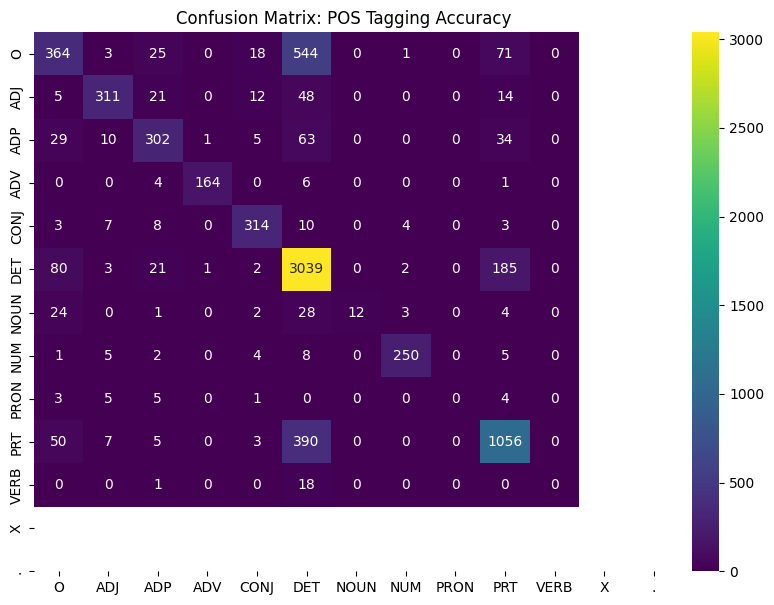


Results for: The solar power plant is working efficiently
the          : DET
solar        : NOUN
power        : NOUN
plant        : NOUN
is           : VERB
working      : VERB
efficiently  : ADV


In [11]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer
)

# Download NLTK resources for Ground Truth labeling
# Updated NLTK resources block
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Added this to fix the LookupError
nltk.download('averaged_perceptron_tagger')
nltk.download('universal_tagset')
nltk.download('averaged_perceptron_tagger_eng') # Added for better compatibility in Colab

# 1. SETUP & DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Standard Universal POS Tags
label_list = ["O", "ADJ", "ADP", "ADV", "CONJ", "DET", "NOUN", "NUM", "PRON", "PRT", "VERB", "X", "."]
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}

# 2. DATA PREPROCESSING WITH AUTO-LABELING
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Twitter_Data.csv').dropna().iloc[:1500]
df.head()

def get_pos_labels(text):
    tokens = nltk.word_tokenize(str(text))
    pos_tags = nltk.pos_tag(tokens, tagset='universal')
    return pos_tags

class TwitterTokenDataset(torch.utils.data.Dataset):
    def __init__(self, texts):
        self.texts = texts.tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        # Get real POS tags from NLTK
        pos_data = get_pos_labels(text)
        words = [p[0] for p in pos_data]
        tags = [label2id.get(p[1], 0) for p in pos_data]

        # Tokenize and align labels with BERT sub-words
        encoding = tokenizer(words, is_split_into_words=True, truncation=True,
                             padding='max_length', max_length=64, return_tensors="pt")

        # Create label array filled with -100 (ignore index for loss)
        word_ids = encoding.word_ids()
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            else:
                label_ids.append(tags[word_idx] if word_idx < len(tags) else 0)

        item = {key: val.squeeze() for key, val in encoding.items()}
        item['labels'] = torch.tensor(label_ids)
        return item

# Split and Create Datasets
train_df, test_df = train_test_split(df['clean_text'], test_size=0.2, random_state=42)
train_dataset = TwitterTokenDataset(train_df)
test_dataset = TwitterTokenDataset(test_df)

# 3. METRICS & EXPERIMENTS
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=2)
    true_labels = labels.flatten()
    true_preds = predictions.flatten()
    mask = true_labels != -100

    precision, recall, f1, _ = precision_recall_fscore_support(true_labels[mask], true_preds[mask], average='weighted')
    return {"accuracy": accuracy_score(true_labels[mask], true_preds[mask]), "f1": f1}

training_args = TrainingArguments(
    output_dir="./results", num_train_epochs=2, per_device_train_batch_size=16,
    eval_strategy="epoch", report_to="none"
)

# Run Fine-Tuning (Last 2 Layers)
model = AutoModelForTokenClassification.from_pretrained(model_ckpt, num_labels=len(label_list)).to(device)
for param in model.distilbert.parameters(): param.requires_grad = False
for param in model.distilbert.transformer.layer[-2:].parameters(): param.requires_grad = True

trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset,
                  eval_dataset=test_dataset, compute_metrics=compute_metrics)

trainer.train()

# 4. FINAL VISUALIZATION (Confusion Matrix)
output = trainer.predict(test_dataset)
preds = np.argmax(output.predictions, axis=2).flatten()
labs = output.label_ids.flatten()
mask = labs != -100

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(labs[mask], preds[mask]), annot=True, fmt='d',
            xticklabels=label_list, yticklabels=label_list, cmap='viridis')
plt.title("Confusion Matrix: POS Tagging Accuracy")
plt.show()

# 5. REAL TEST SAMPLES
def final_test(text):
    model.eval()
    inputs = tokenizer(text.split(), is_split_into_words=True, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    preds = torch.argmax(logits, dim=2).cpu().numpy()[0]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    print(f"\nResults for: {text}")
    for t, p in zip(tokens, preds):
        if not t.startswith("##") and t not in ['[CLS]', '[SEP]']:
            print(f"{t:<12} : {id2label[p]}")

final_test("The solar power plant is working efficiently")